# DRL Weight Comparison: Control Performance


In [1]:
from drl_weight_plot_utils import (
    build_model_specs,
    load_raindata,
    load_record,
    pick_events_by_peak_gradient,
    plot_control_performance_figure,
    set_plot_style,
)

set_plot_style()

In [ ]:
# Core configuration
RESULTS_DIR = 'results_weights'
REAL_RESULTS_DIR = 'results_m_real_weights'
FIGURE_PATH = 'figures_drl_weight_compare/control_performance_drl_weights.png'

START_IDX = 50
NUM_RAINFALLS = 30
ONE_STEP_MINUTES = 5
N_PICK = 4
REAL_EVENTS = [0, 1, 2, 3]

# Baseline record used for improvement calculation
BASELINE_FILE = 'HC.npy'
BASELINE_PATH = ['env4']

DRL_MODELS = [
    {'label': '(0.9,0.1)', 'file': 'DQN3_GI_new_91.npy'},
    {'label': '(0.8,0.2)', 'file': 'DQN3_GI_new_82.npy'},
    {'label': '(0.7,0.3)', 'file': 'DQN3_GI_new_73.npy'},
    {'label': '(0.6,0.4)', 'file': 'DQN3_GI_new_64.npy'},
    {'label': '(0.5,0.5)', 'file': 'DQN3_GI_new_55.npy'},
]

DRL_MODELS


[{'label': '(0.9,0.1)', 'file': 'DQN3_GI_new_91.npy'},
 {'label': '(0.8,0.2)', 'file': 'DQN3_GI_new_82.npy'},
 {'label': '(0.7,0.3)', 'file': 'DQN3_GI_new_73.npy'},
 {'label': '(0.6,0.4)', 'file': 'DQN3_GI_new_64.npy'},
 {'label': '(0.5,0.5)', 'file': 'DQN3_GI_new_55.npy'}]

In [3]:
raindata = load_raindata()
rain_ids = list(range(START_IDX, START_IDX + NUM_RAINFALLS))
baseline_record = load_record(f'results/{BASELINE_FILE}')
model_specs = build_model_specs(DRL_MODELS, results_dir=RESULTS_DIR)
real_model_specs = build_model_specs(DRL_MODELS, results_dir=REAL_RESULTS_DIR)
chosen_events, chosen_peaks = pick_events_by_peak_gradient(raindata, START_IDX, NUM_RAINFALLS, N_PICK)

print('Loaded design-rain models:', [spec['label'] for spec in model_specs])
print('Loaded real-rain models:', [spec['label'] for spec in real_model_specs])
print('Selected design events:', chosen_events)
print('Selected peaks:', chosen_peaks)
print('Real events:', REAL_EVENTS)


Loaded design-rain models: ['(0.9,0.1)', '(0.8,0.2)', '(0.7,0.3)', '(0.6,0.4)', '(0.5,0.5)']
Loaded real-rain models: ['(0.9,0.1)', '(0.8,0.2)', '(0.7,0.3)', '(0.6,0.4)', '(0.5,0.5)']
Selected design events: [70, 64, 67, 51]
Selected peaks: [81.38139521835302, 136.99042512240572, 161.3605100623962, 228.33281936149768]
Real events: [0, 1, 2, 3]


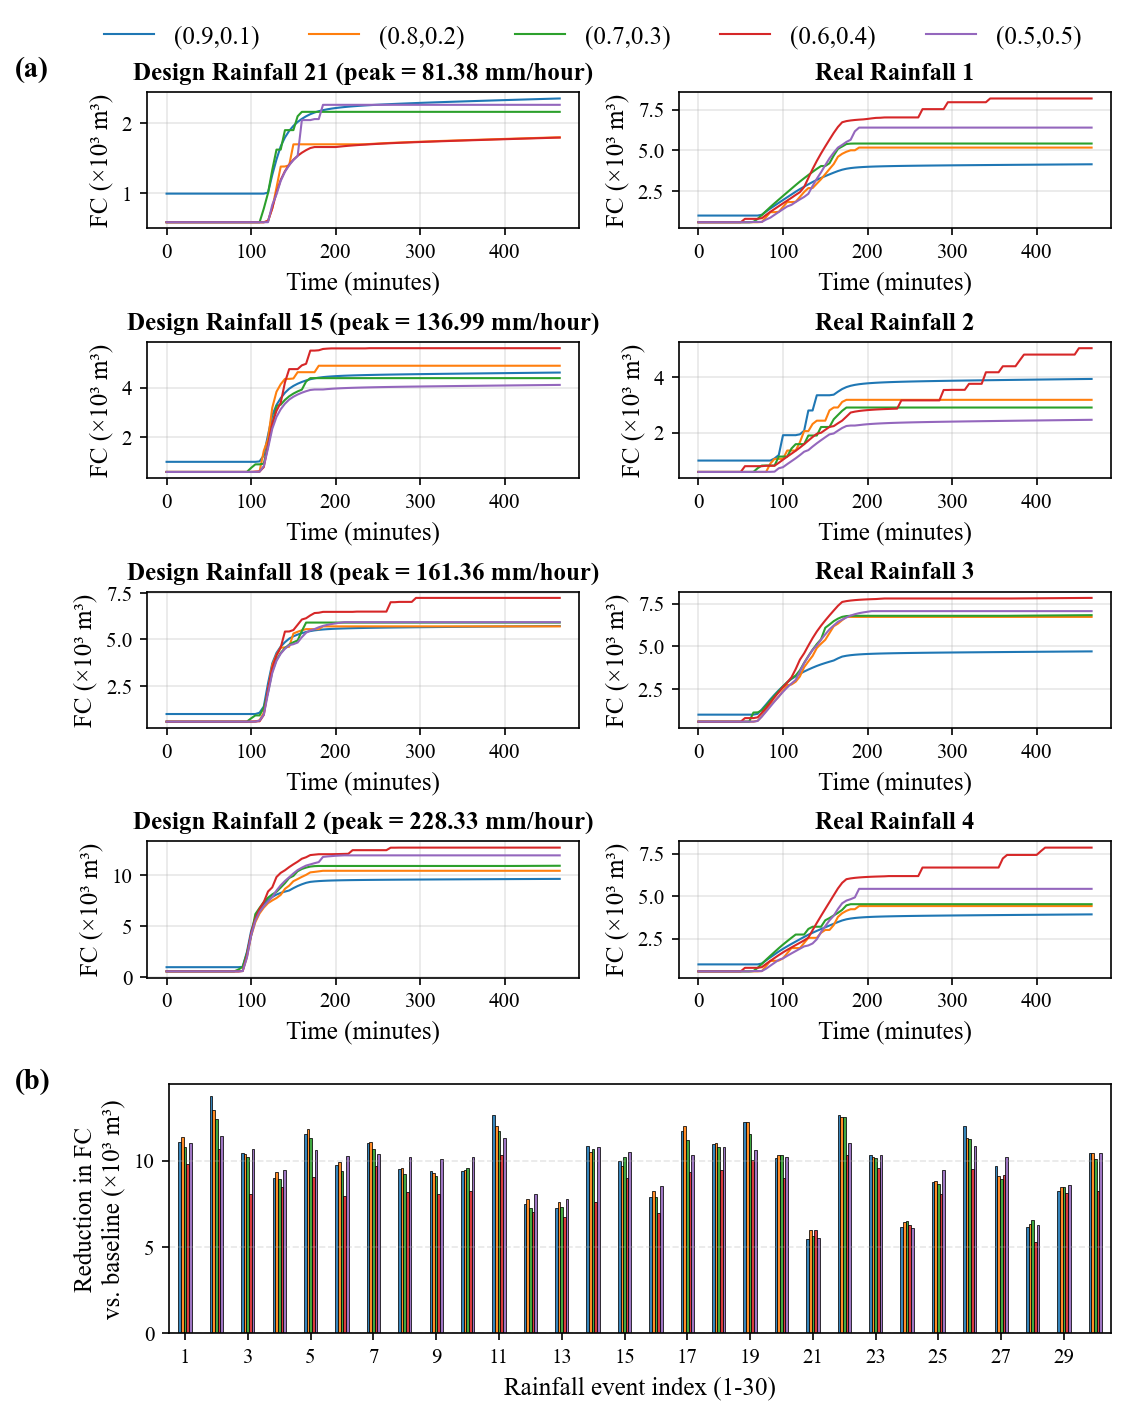

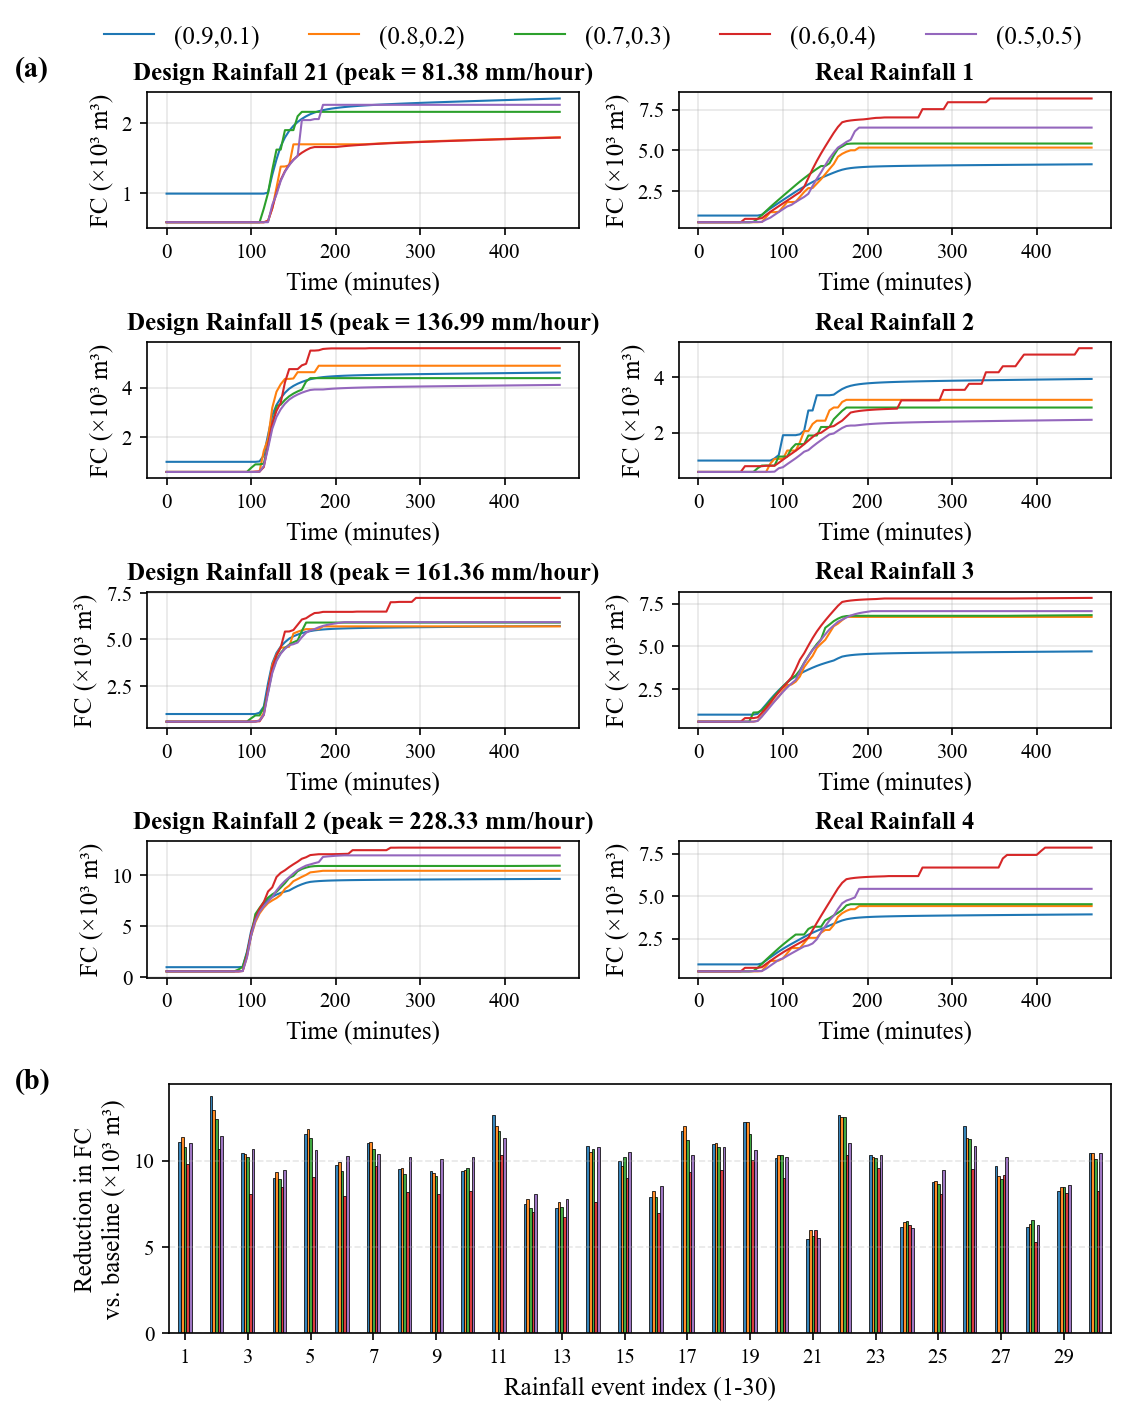

In [4]:
fig, improvements = plot_control_performance_figure(
    model_specs=model_specs,
    base_record=baseline_record,
    base_path=BASELINE_PATH,
    rain_ids=rain_ids,
    chosen_events=chosen_events,
    chosen_peaks=chosen_peaks,
    one_step_minutes=ONE_STEP_MINUTES,
    real_model_specs=real_model_specs,
    real_events=REAL_EVENTS,
    save_path=FIGURE_PATH,
)
fig
